In [ ]:
#####################
#Loading Packages and Reading Data

In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# #Importing Model Data
    
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
# true_time=data['time']
# # parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
# times=data['time'].values/(1e9 * 60); times=times.astype(float);
# Np_str='125e3'
# #Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,140+1))
# # parcel=parcel.isel(time=np.arange(0,140+1))
# res='1km'

dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_1e6.nc') #***
true_time=data['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_1e6.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
Np_str='1e6'
#Restricts the timesteps of the data from timesteps0 to 140
res='1km'
job_array=False;index_adjust=0
ocean_fraction=0.25


# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# # # parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# # # parcel=parcel.isel(time=np.arange(0,400+1))
# res='250m'

In [2]:
if 'emptylike' not in globals():
    print('loading neccessary variables')
    variable='winterp'; w_data=data[variable].data #get w data
    # variable='qv'; qv_data=data[variable].data # get qc data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qc data
    qc_plus_qi=qc_data+qi_data
    # variable='th'; th_data=data[variable].data # get qc data
    # variable='buoyancy'; buoyancy_data=data[variable].data # get qc data
    # qt_data=qv_data+qc_data+qi_data+data['qr'].data+data['qs'].data+data['qg'].data

    variable='rho'; rho_data=data[variable].data
    print('done loading')
    emptylike=True

loading neccessary variables
done loading


In [3]:
pt1_data = data['pt1'].data

Text(0.5, 0.98, 'passive tracer mixing ratio')

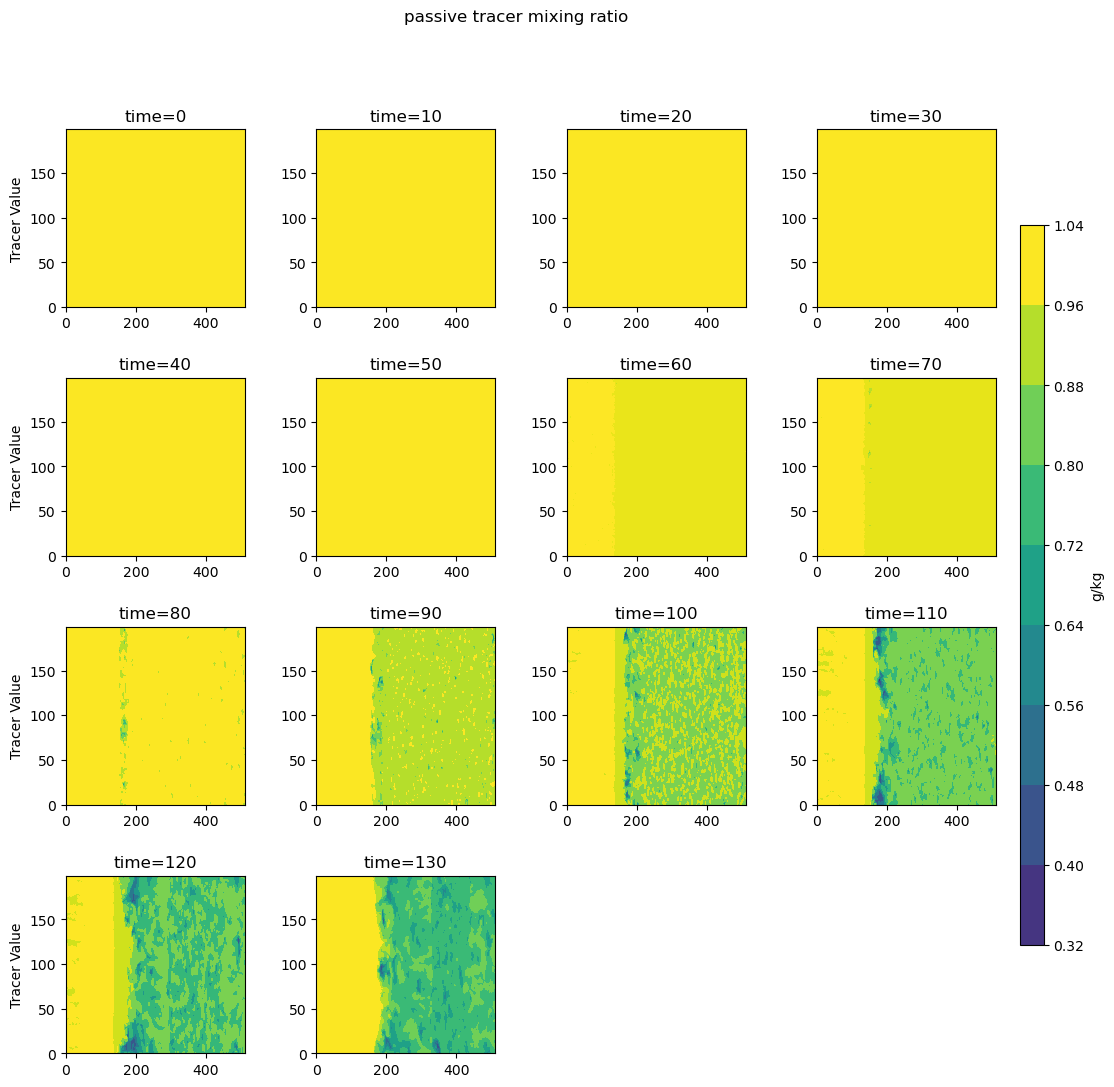

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

pt1_data = data['pt1']*1e3
long_name=data['pt1'].long_name
time_indices = np.arange(0, len(data['time']), 10)
nrows, ncols = 4, 4  # Fixed 4x4 subplot grid

fig = plt.figure(figsize=(12, nrows * 3))
gs = gridspec.GridSpec(nrows, ncols, figure=fig, wspace=0.4, hspace=0.4)

# Determine global colorbar limits
vmin, vmax = pt1_data.isel(zh=1).min(), pt1_data.isel(zh=1).max()

for i, t in enumerate(time_indices[:nrows * ncols]):  # Limit to 4x4 grid
    row, col = divmod(i, ncols)
    ax = fig.add_subplot(gs[row, col])
    plot_data = pt1_data.isel(time=t, zh=1)
    cf = ax.contourf(plot_data, vmin=vmin, vmax=vmax)
    ax.set_title(f'time={t}')
    
    if col == 0:
        ax.set_ylabel("Tracer Value")

# Create a single shared colorbar
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])  # Position of colorbar
fig.colorbar(cf, cax=cbar_ax, orientation='vertical',label='g/kg')

fig.suptitle(f'{long_name}')

In [4]:
#Make threshold binary array for cloudy updrafts
A=np.zeros_like(w_data)
A[:]=0
w_thresh=0.1 #1 #m/s
qcqi_thresh=1e-6 #kg/kg
where=np.where((w_data>=w_thresh) & (qc_plus_qi>=qcqi_thresh))
A[where]=1

In [6]:
def avg(var): #TESTING***
    out=np.mean(var, axis=(2,3)) #takes horizontal average leaving (t,z)
    return out

def ddz(f):
    # f=f.data
    dz=data['zh'].values
    dz=dz.copy()[np.newaxis, :]
    
    _ddz=np.zeros_like(f)
    _ddz[:, 1:-1] = (f[:, 2:] - f[:, :-2]) / (2 * dz[:, 1:-1])
    _ddz[:, 0] = (f[:, 1] - f[:, 0]) / dz[:, 0]  # Forward difference 
    _ddz[:, -1] = (f[:, -1] - f[:, -2]) / dz[:, -1]  # Backward difference 
    return _ddz

def ddt(f):
    dt=(data['time'][1]-data['time'][0]).item()/1e9
    _ddt=np.zeros_like(f)
    _ddt[1:-1] = (f[2:] - f[:-2]) / (dt)
    _ddt[0] = (f[1] - f[0]) / (dt)  # Forward difference 
    _ddt[-1] = (f[-1] - f[-2]) / (dt)  # Backward difference 
    return _ddt

In [131]:
def nan_divide(a, b):
    return np.divide(a, b, out=np.zeros_like(a, dtype=np.float64), where=(b != 0))

def e_d(type):
    # phi=qt_data #TESTING
    phi = pt1_data.copy()
    phi_e=avg(phi*rho_data*(1-A))/avg(rho_data*(1-A))
    # phi_d=avg(phi*rho_data*w_data*A)/avg(rho_data*w_data*A) 
    phi_d=nan_divide(avg(phi*rho_data*w_data*A),avg(rho_data*w_data*A))
    if type=='e':
        phi_e_d=phi_d
    elif type=='d':
        phi_e_d=phi_e

    RHS1 = ddt(avg(rho_data*A)) + ddz(avg(rho_data*w_data*A))
    RHS2 = ddt(avg(phi*rho_data*A)) + ddz(avg(phi*rho_data*w_data*A))
    RHS = (phi_e_d * RHS1) - RHS2

    denominator=(phi_d-phi_e)
    # RHS/=denominator
    RHS=nan_divide(RHS,denominator)
    
    return RHS 
entrain=e_d('e')
detrain=e_d('d')

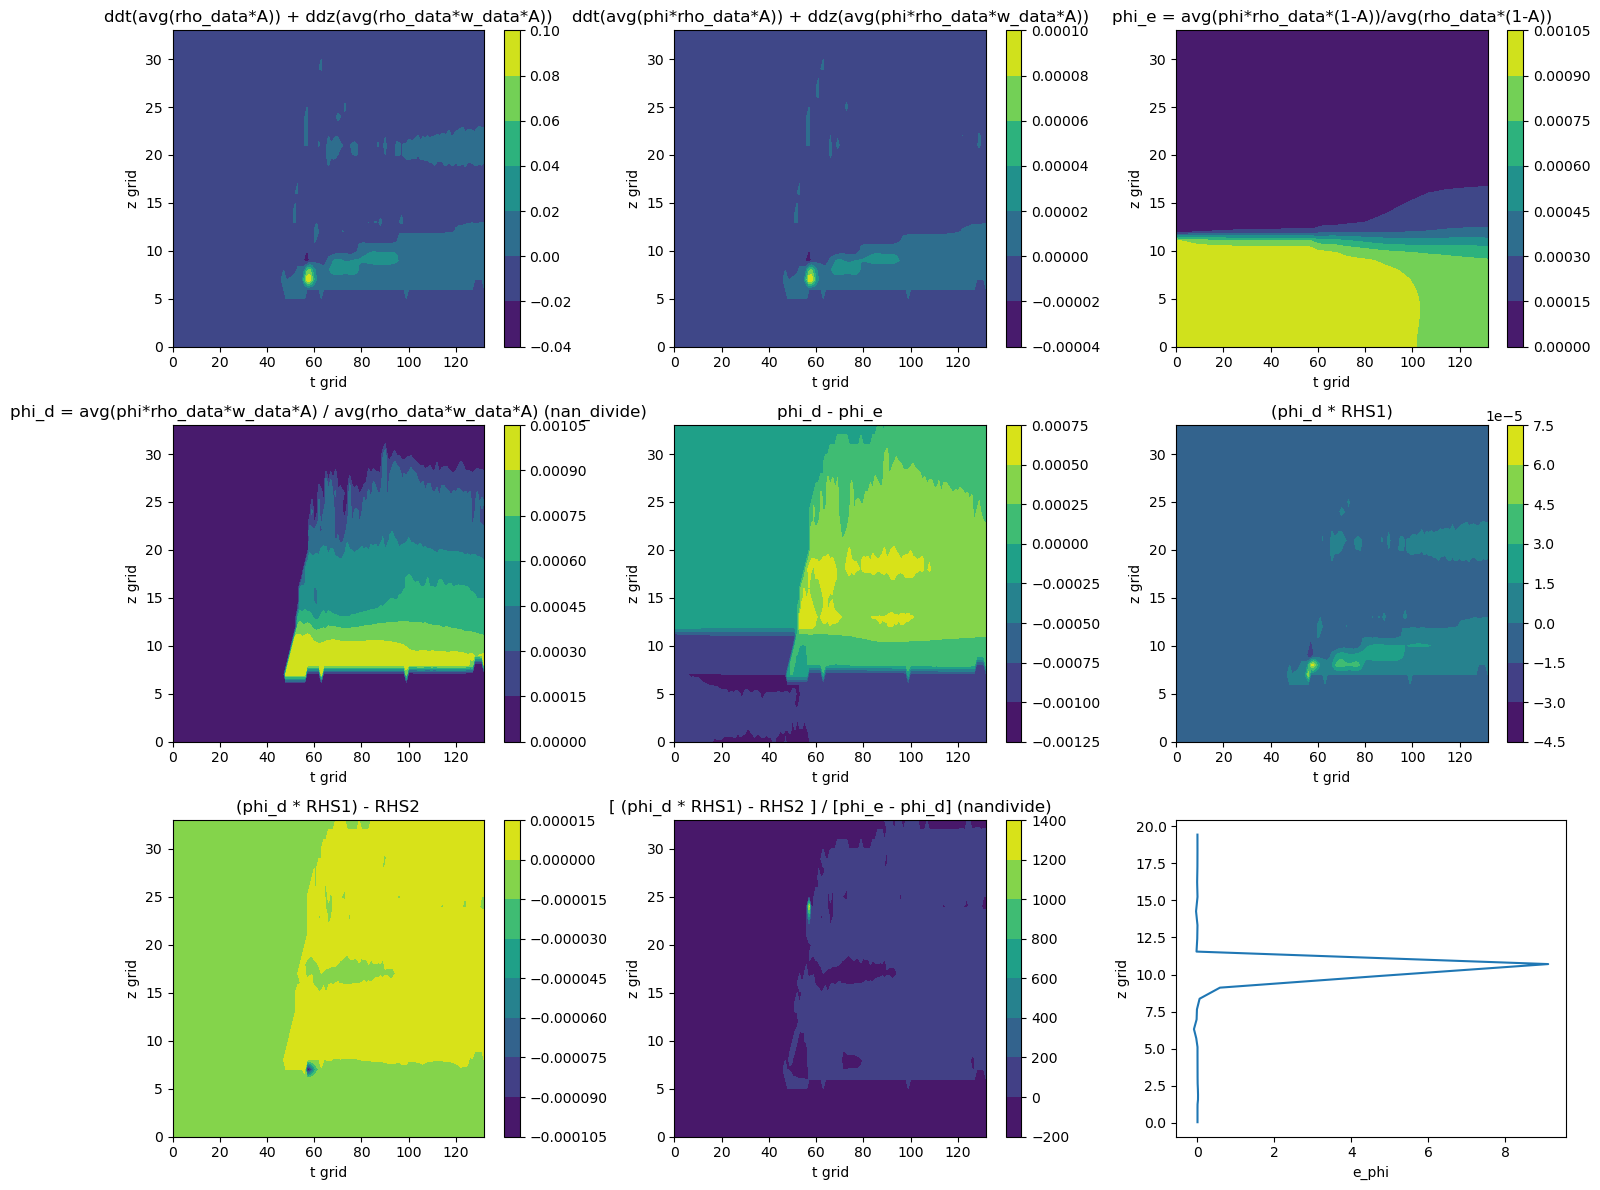

In [135]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Create the figure and GridSpec layout
fig = plt.figure(figsize=(15, 12))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Plot 1: RHS1
ax1 = fig.add_subplot(gs[0, 0])
RHS1 = ddt(avg(rho_data*A)) + ddz(avg(rho_data*w_data*A))
contour1 = ax1.contourf(RHS1.T)
ax1.set_ylabel('z grid')
ax1.set_xlabel('t grid')
ax1.set_title('ddt(avg(rho_data*A)) + ddz(avg(rho_data*w_data*A))')
fig.colorbar(contour1, ax=ax1)

# Plot 2: RHS2
ax2 = fig.add_subplot(gs[0, 1])
RHS2 = ddt(avg(phi*rho_data*A)) + ddz(avg(phi*rho_data*w_data*A))
contour2 = ax2.contourf(RHS2.T)
ax2.set_ylabel('z grid')
ax2.set_xlabel('t grid')
ax2.set_title('ddt(avg(phi*rho_data*A)) + ddz(avg(phi*rho_data*w_data*A))')
fig.colorbar(contour2, ax=ax2)

# Plot 3: PHI_E
ax3 = fig.add_subplot(gs[0, 2])
PHI_E = avg(phi*rho_data*(1-A)) / avg(rho_data*(1-A))
contour3 = ax3.contourf(PHI_E.T)
ax3.set_ylabel('z grid')
ax3.set_xlabel('t grid')
ax3.set_title('phi_e = avg(phi*rho_data*(1-A))/avg(rho_data*(1-A))')
fig.colorbar(contour3, ax=ax3)

# Plot 4: PHI_D
ax4 = fig.add_subplot(gs[1, 0])
PHI_D = nan_divide(avg(phi*rho_data*w_data*A), avg(rho_data*w_data*A))
contour4 = ax4.contourf(PHI_D.T)
ax4.set_ylabel('z grid')
ax4.set_xlabel('t grid')
ax4.set_title('phi_d = avg(phi*rho_data*w_data*A) / avg(rho_data*w_data*A) (nan_divide)')
fig.colorbar(contour4, ax=ax4)

# Plot 5: PHI_NET
ax5 = fig.add_subplot(gs[1, 1])
PHI_NET = PHI_D - PHI_E
contour5 = ax5.contourf(PHI_NET.T)
ax5.set_ylabel('z grid')
ax5.set_xlabel('t grid')
ax5.set_title('phi_d - phi_e')
fig.colorbar(contour5, ax=ax5)

# Plot 6: (phi_d * RHS1)
ax6 = fig.add_subplot(gs[1, 2])
phi_e_d = PHI_D
RHS3 = (phi_e_d * RHS1)
contour6 = ax6.contourf(RHS3.T)
ax6.set_ylabel('z grid')
ax6.set_xlabel('t grid')
ax6.set_title('(phi_d * RHS1)')
fig.colorbar(contour6, ax=ax6)

# Plot 7: (phi_d * RHS1) - RHS2
ax7 = fig.add_subplot(gs[2, 0])
phi_e_d = PHI_D
RHS = (phi_e_d * RHS1) - RHS2
contour7 = ax7.contourf(RHS.T)
ax7.set_ylabel('z grid')
ax7.set_xlabel('t grid')
ax7.set_title('(phi_d * RHS1) - RHS2')
fig.colorbar(contour7, ax=ax7)

# Plot 8: (phi_d * RHS1) - RHS2 (nan_divide)
ax8 = fig.add_subplot(gs[2, 1])
TOTAL = nan_divide(RHS, PHI_NET)
contour8 = ax8.contourf(TOTAL.T)
ax8.set_ylabel('z grid')
ax8.set_xlabel('t grid')
ax8.set_title('[ (phi_d * RHS1) - RHS2 ] / [phi_e - phi_d] (nandivide)')
fig.colorbar(contour8, ax=ax8) 

# Plot 9: Vertical Profile
ax9 = fig.add_subplot(gs[2, 2])
vert = np.mean(TOTAL, axis=0)
ax9.plot(vert, data['zh'])
ax9.set_ylabel('z grid')
ax9.set_xlabel('e_phi')

# Adjust layout to prevent overlap
plt.tight_layout()


Text(0.5, 1.0, 'entrainment')

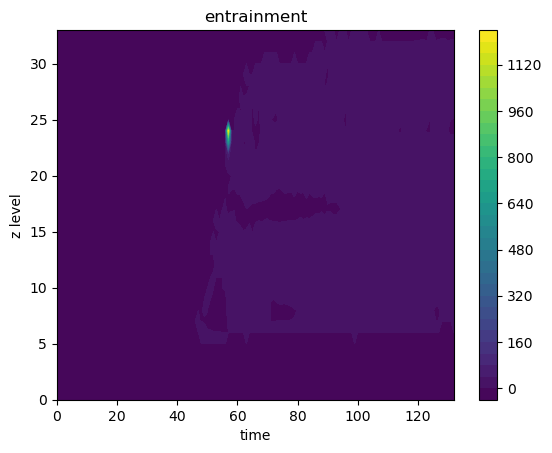

In [133]:
plt.contourf(entrain.T,levels=30)
plt.colorbar()
plt.xlabel('time');plt.ylabel('z level')
plt.title('entrainment')

Text(0.5, 1.0, 'detrainment')

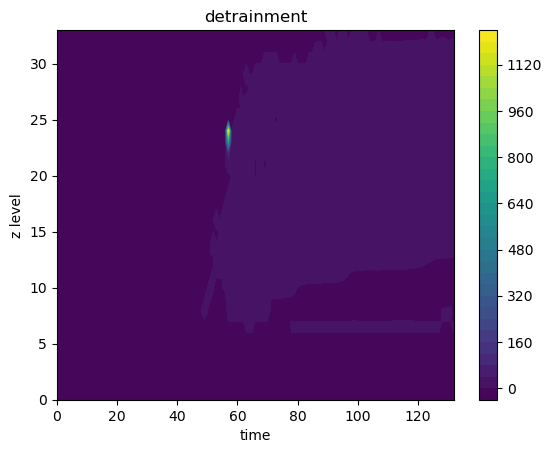

In [9]:
plt.contourf(detrain.T,levels=30)
plt.colorbar()
plt.xlabel('time');plt.ylabel('z level')
plt.title('detrainment')

Text(0, 0.5, 'z level')

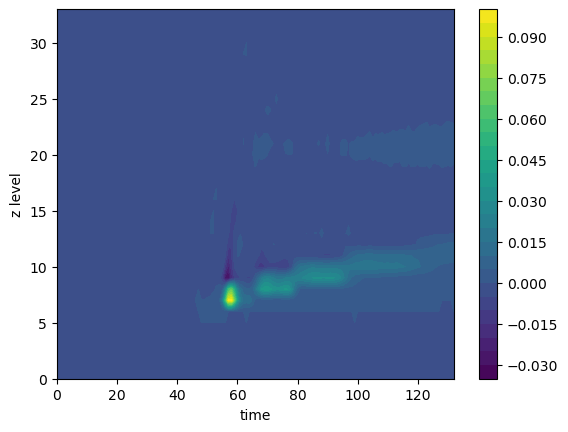

In [10]:
mixed=entrain-detrain
plt.contourf(mixed.T,levels=30)
plt.colorbar()
plt.xlabel('time');plt.ylabel('z level')

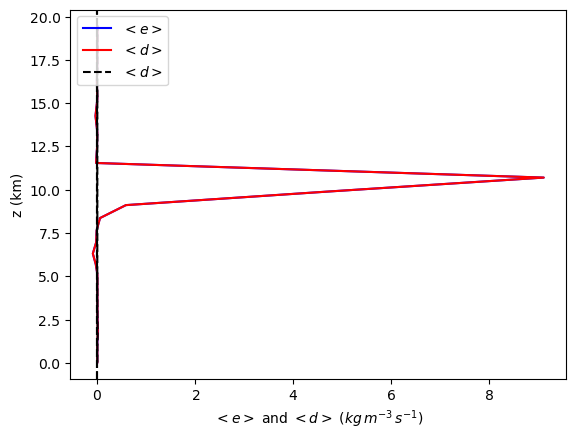

In [14]:
entrain_mean=np.nanmean(entrain,axis=0)
# entrain_mean[20:]=0#TESTING
plt.plot(entrain_mean,data['zh'].values,color='blue',label='$<e>$')

detrain_mean=np.nanmean(detrain,axis=0)
# detrain_mean[20:]=0#TESTING
plt.plot(detrain_mean,data['zh'].values,color='red',label='$<d>$')
plt.axvline(0,color='k',linestyle='dashed')

net_mean=np.nanmean(entrain-detrain,axis=0)
plt.plot(net_mean,data['zh'].values,linestyle='dashed',color='black',label='$<d>$')
plt.axvline(0,color='k',linestyle='dashed')

plt.legend(loc='upper left')
plt.xlabel('$<e>$ and $<d>$ ($kg\,m^{-3}\,s^{-1}$)');plt.ylabel('z (km)')

from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 3))
plt.gca().xaxis.set_major_formatter(formatter)  

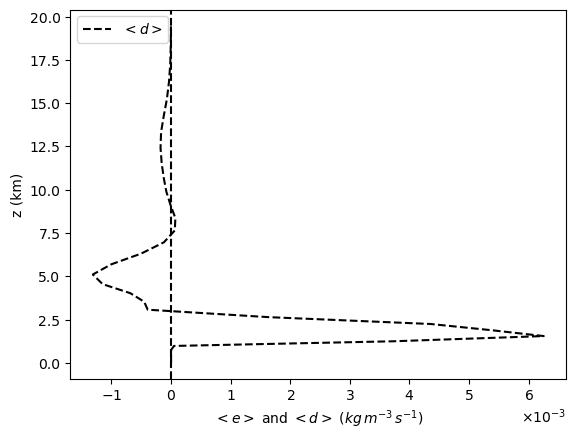

In [12]:

net_mean=np.nanmean(entrain-detrain,axis=0)
plt.plot(net_mean,data['zh'].values,linestyle='dashed',color='black',label='$<d>$')
plt.axvline(0,color='k',linestyle='dashed')

plt.legend(loc='upper left')
plt.xlabel('$<e>$ and $<d>$ ($kg\,m^{-3}\,s^{-1}$)');plt.ylabel('z (km)')

from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 3))
plt.gca().xaxis.set_major_formatter(formatter)  

In [74]:
#ESTIMATES FOR FRACTIONAL ENTRAINMENT/DETRAINMENT
############################################################

def e_d_f(type):
    phi = pt1_data.copy()
    
    one=np.log(avg(rho_data*w_data*A))
    two=np.log(avg(phi*rho_data*w_data*A))
    if type=='e':
        OUT=ddz(one)-ddz(two)
    if type=='d':
        OUT=-ddz(two)    

    # OUT=np.where(np.isnan(OUT), 0, OUT)
    return OUT
entrain=e_d_f('e')
detrain=e_d_f('d')

/tmp/ipykernel_2572515/51561230.py:7: RuntimeWarning: divide by zero encountered in log
  one=np.log(avg(rho_data*w_data*A))
/tmp/ipykernel_2572515/51561230.py:8: RuntimeWarning: divide by zero encountered in log
  two=np.log(avg(phi*rho_data*w_data*A))
/tmp/ipykernel_2572515/3125354492.py:11: RuntimeWarning: invalid value encountered in subtract
  _ddz[:, 1:-1] = (f[:, 2:] - f[:, :-2]) / (2 * dz[:, 1:-1])
/tmp/ipykernel_2572515/3125354492.py:12: RuntimeWarning: invalid value encountered in subtract
  _ddz[:, 0] = (f[:, 1] - f[:, 0]) / dz[:, 0]  # Forward difference
/tmp/ipykernel_2572515/3125354492.py:13: RuntimeWarning: invalid value encountered in subtract
  _ddz[:, -1] = (f[:, -1] - f[:, -2]) / dz[:, -1]  # Backward difference
/tmp/ipykernel_2572515/51561230.py:10: RuntimeWarning: invalid value encountered in subtract
  OUT=ddz(one)-ddz(two)


/tmp/ipykernel_2572515/3382442102.py:8: RuntimeWarning: divide by zero encountered in log
  one = np.log(avg(rho_data * w_data * A))  # Keep your original avg function
/tmp/ipykernel_2572515/3125354492.py:11: RuntimeWarning: invalid value encountered in subtract
  _ddz[:, 1:-1] = (f[:, 2:] - f[:, :-2]) / (2 * dz[:, 1:-1])
/tmp/ipykernel_2572515/3125354492.py:12: RuntimeWarning: invalid value encountered in subtract
  _ddz[:, 0] = (f[:, 1] - f[:, 0]) / dz[:, 0]  # Forward difference
/tmp/ipykernel_2572515/3125354492.py:13: RuntimeWarning: invalid value encountered in subtract
  _ddz[:, -1] = (f[:, -1] - f[:, -2]) / dz[:, -1]  # Backward difference
/tmp/ipykernel_2572515/3382442102.py:28: RuntimeWarning: divide by zero encountered in log
  two = np.log(avg(phi * rho_data * w_data * A))  # Keep your original avg function
/tmp/ipykernel_2572515/3382442102.py:47: RuntimeWarning: invalid value encountered in subtract
  diff = ddz1 - ddz2  # Keep your original diff calculation
/tmp/ipykernel_

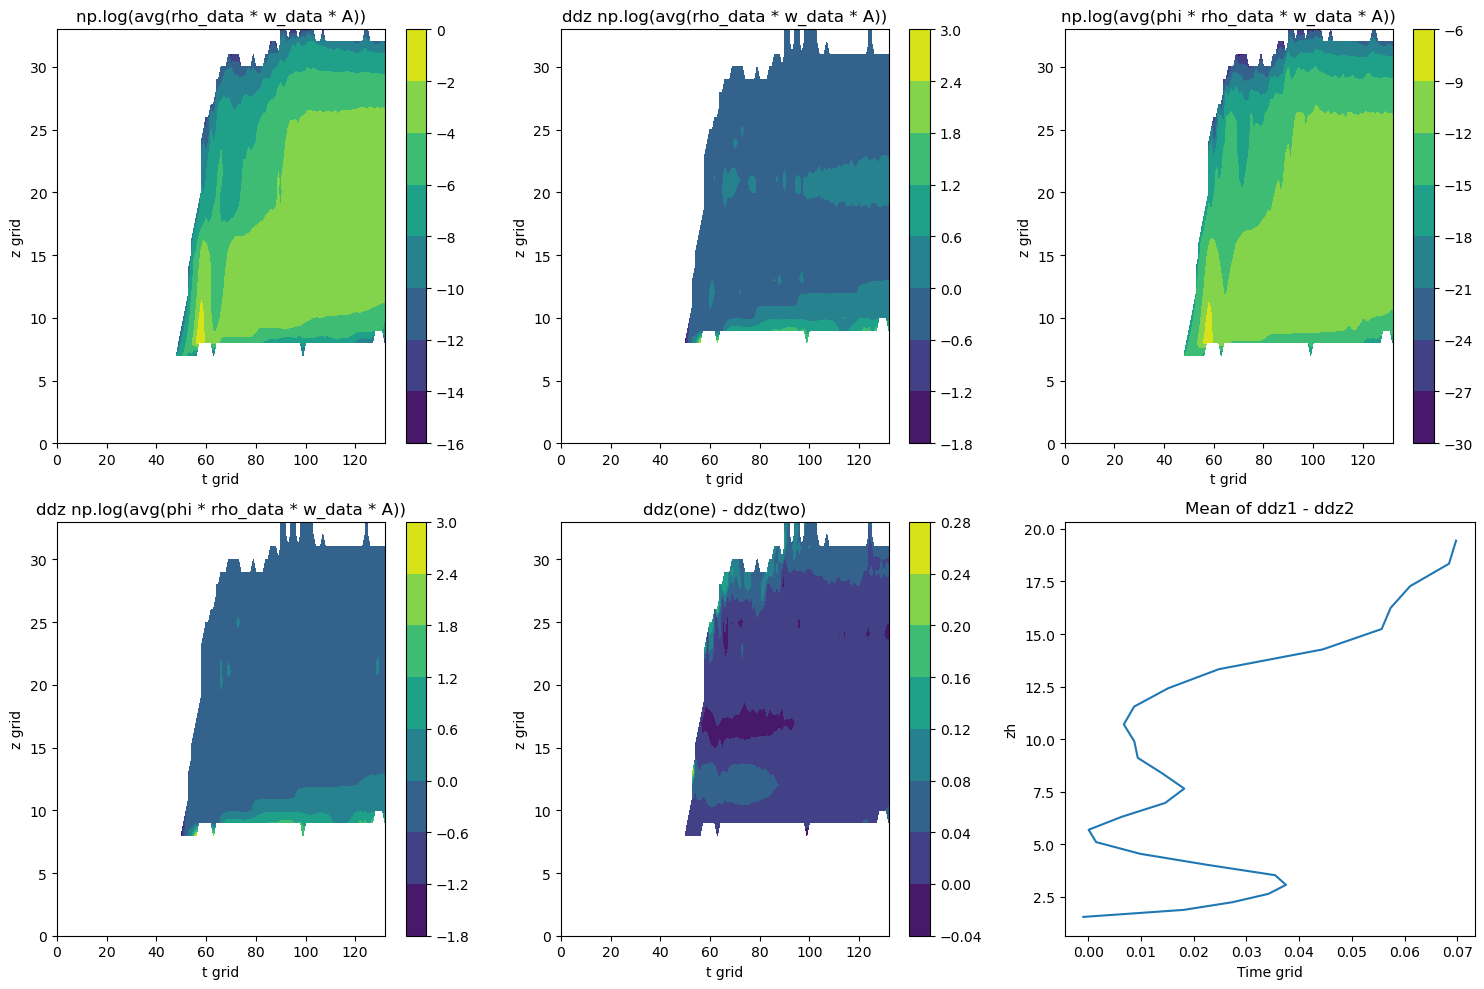

In [91]:
#TESTING
import matplotlib.pyplot as plt
import numpy as np

# Create a 2x3 GridSpec layout for the plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: np.log(avg(rho_data * w_data * A))
one = np.log(avg(rho_data * w_data * A))  # Keep your original avg function
# one = np.where(np.isneginf(one), 0, one)  # Optional to handle -inf as 0
ax1 = axes[0, 0]
c1 = ax1.contourf(one.T)
fig.colorbar(c1, ax=ax1)
ax1.set_ylabel('z grid')
ax1.set_xlabel('t grid')
ax1.set_title('np.log(avg(rho_data * w_data * A))')

# Plot 2: ddz np.log(avg(rho_data * w_data * A))
ddz1 = ddz(one)  # Keep your original ddz calculation
ax2 = axes[0, 1]
c2 = ax2.contourf(ddz1.T)
fig.colorbar(c2, ax=ax2)
ax2.set_ylabel('z grid')
ax2.set_xlabel('t grid')
ax2.set_title('ddz np.log(avg(rho_data * w_data * A))')

# Plot 3: np.log(avg(phi * rho_data * w_data * A))
phi = pt1_data.copy()  # Keep your original phi calculation
two = np.log(avg(phi * rho_data * w_data * A))  # Keep your original avg function
# two = np.where(np.isneginf(two), 0, two)  # Optional to handle -inf as 0
ax3 = axes[0, 2]
c3 = ax3.contourf(two.T)
fig.colorbar(c3, ax=ax3)
ax3.set_ylabel('z grid')
ax3.set_xlabel('t grid')
ax3.set_title('np.log(avg(phi * rho_data * w_data * A))')

# Plot 4: ddz np.log(avg(phi * rho_data * w_data * A))
ddz2 = ddz(two)  # Keep your original ddz calculation
ax4 = axes[1, 0]
c4 = ax4.contourf(ddz2.T)
fig.colorbar(c4, ax=ax4)
ax4.set_ylabel('z grid')
ax4.set_xlabel('t grid')
ax4.set_title('ddz np.log(avg(phi * rho_data * w_data * A))')

# Plot 5: ddz(one) - ddz(two)
diff = ddz1 - ddz2  # Keep your original diff calculation
ax5 = axes[1, 1]
c5 = ax5.contourf(diff.T)
fig.colorbar(c5, ax=ax5)
ax5.set_ylabel('z grid')
ax5.set_xlabel('t grid')
ax5.set_title('ddz(one) - ddz(two)')

# Plot 6: Plot mean of the difference
ax6 = axes[1, 2]
ax6.plot(np.nanmean(diff, axis=0), data['zh'])  # Keep your original mean calculation
ax6.set_ylabel('zh')
ax6.set_xlabel('Time grid')
ax6.set_title('Mean of ddz1 - ddz2')

# Adjust layout for better spacing
plt.tight_layout()


In [80]:
# plt.contourf(entrain.T,levels=30)
# plt.colorbar()
# plt.xlabel('time');plt.ylabel('z level')
# plt.title('entrainment')

In [81]:
# plt.contourf(detrain.T,levels=30)
# plt.colorbar()
# plt.xlabel('time');plt.ylabel('z level')
# plt.title('detrainment')

In [82]:
# mixed=entrain-detrain
# plt.contourf(mixed.T,levels=30)
# plt.colorbar()
# plt.xlabel('time');plt.ylabel('z level')

In [83]:
# entrain_mean=np.nanmean(entrain,axis=0)
# # entrain_mean[20:]=0#TESTING
# plt.plot(entrain_mean,data['zh'].values,color='blue',label='$<e>$')

# detrain_mean=np.nanmean(detrain,axis=0)
# # detrain_mean[20:]=0#TESTING
# plt.plot(detrain_mean,data['zh'].values,color='red',label='$<d>$')
# plt.axvline(0,color='k',linestyle='dashed')

# net_mean=np.nanmean(entrain-detrain,axis=0)
# plt.plot(net_mean,data['zh'].values,linestyle='dashed',color='black',label='$<e>-<d>$')
# plt.axvline(0,color='k',linestyle='dashed')

# plt.legend(loc='upper left')
# plt.xlabel('$<e>$ and $<d>$ ($kg\,m^{-3}\,s^{-1}$)');plt.ylabel('z (km)')

# from matplotlib.ticker import ScalarFormatter
# formatter = ScalarFormatter(useMathText=True)
# formatter.set_powerlimits((-3, 3))
# plt.gca().xaxis.set_major_formatter(formatter)  

In [ ]:
# #DIAGNOSTIC CALCULATION
# def ddz(f):
#     # f=f.data
#     dz=data['zh'].values
#     dz=dz.copy()[np.newaxis, :, np.newaxis, np.newaxis]
    
#     _ddz=np.zeros_like(f)
#     _ddz[:, 1:-1, :, :] = (f[:, 2:, :, :] - f[:, :-2, :, :]) / (2 * dz[:, 1:-1])
#     _ddz[:, 0, :, :] = (f[:, 1, :, :] - f[:, 0, :, :]) / dz[:, 0]  # Forward difference 
#     _ddz[:, -1, :, :] = (f[:, -1, :, :] - f[:, -2, :, :]) / dz[:, -1]  # Backward difference 
#     return _ddz

# def ddy(f):
#     # f=f.data
#     dy=1000
    
#     _ddy=np.zeros_like(f)
#     _ddy[:, :, 1:-1, :] = (f[:, :, 2:, :] - f[:, :, :-2, :]) / (2 * dy)
#     _ddy[:, :, 0, :] = (f[:, :, 1, :] - f[:, :, 0, :]) / dy  # Forward difference 
#     _ddy[:, :, -1, :] = (f[:, :, -1, :] - f[:, :, -2, :]) / dy  # Backward difference 
#     return _ddy

# def ddx(f):
#     # f=f.data
#     dx=1000
    
#     _ddx=np.zeros_like(f)
#     _ddx[:, :, :, 1:-1] = (f[:, :, :, 2:] - f[:, :, :, :-2]) / (2 * dx)
#     _ddx[:, :, :, 0] = (f[:, :, :, 1] - f[:, :, :, 0]) / dx  # Forward difference 
#     _ddx[:, :, :, -1] = (f[:, :, :, -1] - f[:, :, :, -2]) / dx  # Backward difference 
#     return _ddx

# def div(f):
#     _div=ddz(f)+ddy(f)+ddx(f)
#     return _div

# def e_d(type): #TESTING***

#     if type=='e':
#         RHS=ddt(rho_data*A)+div(rho_data*w_data*A)  
#         # RHS=np.max(np.zeros_like(RHS),RHS)
#         RHS[np.where(RHS<=0)]=0
#     elif type=='d':
#         RHS=-ddt(rho_data*A)-div(rho_data*w_data*A)
#         # RHS=np.max(np.zeros_like(RHS),RHS)
#         RHS[np.where(RHS<=0)]=0
    
#     return RHS

# entrain=e_d('e')
# # detrain=e_d('d')


# ########################################################################
# entrain_mean=np.mean(entrain,axis=(2,3))

# import matplotlib.gridspec as gridspec
# fig = plt.figure(figsize=(15, 6))
# gs = gridspec.GridSpec(1, 2, width_ratios=[1.5, 1])  # 1 row, 2 columns

# # Create the first subplot (contour plot)
# ax0 = fig.add_subplot(gs[0])
# c = ax0.contourf(entrain_mean.T,levels=30)
# fig.colorbar(c, ax=ax0)
# ax0.set_xlabel('Time')
# ax0.set_ylabel('Z level')

# # Create the second subplot (line plot)
# ax1 = fig.add_subplot(gs[1])
# ax1.plot(entrain_mean[33], data['zh'].values)
# ax1.set_xlabel('Time')
# ax1.set_ylabel('Z level')

# fig.suptitle('Entrainment Diagnostic')

In [ ]:
# # detrain=e_d('d')

# # detrain_mean=np.mean(detrain,axis=(2,3))


# ########################################################################
# import matplotlib.gridspec as gridspec
# fig = plt.figure(figsize=(15, 6))
# gs = gridspec.GridSpec(1, 2, width_ratios=[1.5, 1])  # 1 row, 2 columns

# # Create the first subplot (contour plot)
# ax0 = fig.add_subplot(gs[0])
# c = ax0.contourf(detrain_mean.T,levels=30)
# fig.colorbar(c, ax=ax0)
# ax0.set_xlabel('Time')
# ax0.set_ylabel('Z level')

# # Create the second subplot (line plot)
# ax1 = fig.add_subplot(gs[1])
# ax1.plot(detrain_mean[10], data['zh'].values)
# ax1.set_xlabel('Time')
# ax1.set_ylabel('Z level')

# fig.suptitle('Detrainment Diagnostic')

In [ ]:
# mixed=entrain_mean-detrain_mean

# ########################################################################
# import matplotlib.gridspec as gridspec

# fig = plt.figure(figsize=(15, 6))
# gs = gridspec.GridSpec(1, 2, width_ratios=[1.5, 1])  # 1 row, 2 columns

# # Create the first subplot (line plot)
# ax0 = fig.add_subplot(gs[0])
# c = ax0.contourf(mixed.T,levels=30)
# fig.colorbar(c, ax=ax0)
# ax0.set_xlabel('Time')
# ax0.set_ylabel('Z level')

# # Create the second subplot (line plot)
# ax1 = fig.add_subplot(gs[1])
# ax1.plot(mixed[10], data['zh'].values)
# ax1.set_xlabel('Time')
# ax1.set_ylabel('Z level')

# fig.suptitle('Entrainment - Detrainment Diagnostic')